# FinOptiX — S&P 500 Portfolio Optimization with Multi-Model Forecasting

**Objective:** Leverage portfolio optimization with data analytics to maximize risk-adjusted returns on S&P 500 constituents.

**Pipeline:**
1. Data acquisition — multi-year S&P 500 OHLCV data
2. Fama-French 5-Factor model via OLS regression — factor-implied expected returns
3. XGBoost & Random Forest — rank stocks by upward potential (forward-return classification/regression)
4. LSTM — sequential modeling of multivariate OHLCV dependencies
5. ARIMA (statsmodels) — univariate time series forecasting capturing seasonality/trend
6. Signal blending + Mean-Variance portfolio optimization
7. Backtest vs. S&P 500 benchmark — cumulative return, annualized outperformance, portfolio beta

> **Note on execution environment:** This notebook is designed to run in Google Colab or a local Jupyter environment with internet access (Yahoo Finance + Kenneth French Data Library). Cells were authored but not executed in the build environment due to network sandboxing — run top-to-bottom in your own environment to populate all outputs.


## 0. Installing & Importing Libraries

In [ ]:
# Core installs (uncomment if running fresh in Colab)
!pip install -q yfinance pandas-datareader PyPortfolioOpt xgboost statsmodels tensorflow scikit-learn seaborn plotly


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import xgboost as xgb

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns as pf_expected_returns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from tqdm import tqdm

np.random.seed(42)
tf.random.set_seed(42)

pd.set_option('display.max_columns', 50)


## 1. Data Acquisition — S&P 500 Universe

We use a liquid, sector-diversified subset of S&P 500 constituents (large-caps across all 11 GICS sectors) rather than all ~500 names.
This keeps download times and per-ticker model training tractable while remaining representative of the index.

If you want the *full* S&P 500 list, uncomment the Wikipedia-scrape cell below.

In [ ]:
# Representative S&P 500 subset across sectors (40 names).
# Swap in the full list below if you want all ~500 constituents.
tickers = [
    # Technology
    'AAPL', 'MSFT', 'NVDA', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'CSCO',
    # Communication Services
    'GOOGL', 'META', 'NFLX', 'DIS',
    # Consumer Discretionary
    'AMZN', 'TSLA', 'HD', 'MCD', 'NKE',
    # Consumer Staples
    'PG', 'KO', 'PEP', 'WMT', 'COST',
    # Financials
    'JPM', 'BAC', 'WFC', 'GS', 'V', 'MA',
    # Healthcare
    'UNH', 'JNJ', 'LLY', 'PFE', 'ABBV',
    # Industrials
    'CAT', 'HON', 'UPS', 'GE',
    # Energy
    'XOM', 'CVX',
    # Utilities / Real Estate / Materials
    'NEE', 'LIN'
]

benchmark_ticker = '^GSPC'  # S&P 500 index itself, used as the backtest benchmark

print(f'Universe size: {len(tickers)} tickers')


Universe size: 41 tickers


In [ ]:
# Optional: scrape the full current S&P 500 list from Wikipedia instead of the
# hand-picked subset above. Uncomment to use.

# sp500_table = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
# tickers = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()
# print(f'Full S&P 500 universe: {len(tickers)} tickers')


In [ ]:
start_date = '2022-01-01'
end_date = '2024-12-31'   # ~3 years: gives room for a 2-year out-of-sample backtest window

data = yf.download(tickers, start=start_date, end=end_date, interval='1d', group_by='ticker', auto_adjust=True)
benchmark = yf.download(benchmark_ticker, start=start_date, end=end_date, interval='1d', auto_adjust=True)

print(data.shape)
data.head()


[*********************100%***********************]  41 of 41 completed
[*********************100%***********************]  1 of 1 completed


(752, 205)


Ticker            ABBV                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2022-01-03  114.885548  115.131586  113.273528  114.894028  6839800   
2022-01-04  114.817693  115.572793  114.011690  114.673462  6298300   
2022-01-05  114.537713  117.210254  114.537713  115.275841  7724900   
2022-01-06  115.725485  115.946084  114.673443  114.732826  4667000   
2022-01-07  114.749804  115.250373  113.799570  114.435890  8630300   

Ticker            MSFT                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2022-01-03  323.040354  325.593074  317.674804  322.462372  28865100   
2022-01-04  322.539387  322.895831  314.149114  316.933044  32674300   
2022-01-05  313.898725  314.101038  304.381412  304.766724  40054300   
2022-01-06  301.655214  307.001509  300.056144  302.358429  39646100   
2022-01-07  302.618521  304.882266  298.707554  302.512573  32720000   

Ticker             LLY                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2022-01-03  263.461925  263.461925  256.405160  260.888855  2621300   
2022-01-04  258.267820  259.112716  253.064047  256.165192  2340500   
2022-01-05  257.461316  258.046965  250.030126  250.250931  3004200   
2022-01-06  249.722880  250.874986  245.268001  248.983582  2863200   
2022-01-07  249.377251  250.827016  246.468139  249.146835  2245100   

Ticker           GOOGL                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2022-01-03  143.780082  144.569091  142.449881  143.717148  28646000   
2022-01-04  144.118057  145.197490  142.453330  143.130325  28400000   
2022-01-05  143.150656  143.229456  136.477831  136.564056  54618000   
2022-01-06  135.794379  138.710023  135.358244  136.536789  37348000   
2022-01-07  136.931274  137.231620  134.573186  135.812698  29760000   

Ticker            BAC                                             ...  \
Price            Open       High        Low      Close    Volume  ...   
Date                                                              ...   
2022-01-03  40.291352  41.542360  40.193058  41.265350  58587900  ...   
2022-01-04  42.051695  43.275893  42.033823  42.882721  74606700  ...   
2022-01-05  43.016749  43.222271  42.141045  42.158916  57791600  ...   
2022-01-06  42.873779  43.034623  42.167853  43.007816  52040900  ...   
2022-01-07  43.025693  44.062241  42.945271  43.946075  59082600  ...   

Ticker           ORCL                                                  NFLX  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2022-01-03  82.206635  82.780849  80.728742  82.743195  10644400  60.561001   
2022-01-04  82.743211  84.324651  82.583186  83.628059  11959000  59.991001   
2022-01-05  83.298586  83.402133  81.161762  81.387680  11236700  59.200001   
2022-01-06  81.255414  82.597071  80.830243  81.576653   7918400  55.433998   
2022-01-07  81.680573  83.145063  81.519954  82.682098   9836800  54.945999   

Ticker                                                         GS              \
Price            High        Low      Close    Volume        Open        High   
Date                                                                            
2022-01-03  60.999001  59.056000  59.737000  30675000  348.121673  357.339279   
2022-01-04  60.041000  58.160000  59.115002  43931000  359.961398  367.165448   
2022-01-05  59.284000  56.688000  56.751999  41487000  366.735862  369.295331   
2022

In [ ]:
# Sanity check — drop any tickers that failed to download / are mostly NaN
valid_tickers = []
for t in tickers:
    try:
        if data[t]['Close'].notna().sum() > 200:
            valid_tickers.append(t)
    except KeyError:
        print(f'Dropping {t} — no data returned')

tickers = valid_tickers
print(f'Usable tickers: {len(tickers)}')


Usable tickers: 41


## 2. Fama-French 5-Factor Model (OLS Regression)

We pull the daily Fama-French 5 factors (Mkt-RF, SMB, HML, RMW, CMA, RF) from Kenneth French's data library
and regress each stock's excess return on the factors:

$$ R_i - R_f = \alpha_i + \beta_{MKT}(R_{MKT}-R_f) + \beta_{SMB} \cdot SMB + \beta_{HML}\cdot HML + \beta_{RMW}\cdot RMW + \beta_{CMA}\cdot CMA + \epsilon_i $$

The fitted factor loadings (betas) and the model's alpha are then used to build a **factor-implied expected return** for each stock,
which becomes one of the signals blended into the final portfolio optimization.

In [ ]:
import pandas_datareader.data as web

ff_start = pd.to_datetime(start_date)
ff_end = pd.to_datetime(end_date)

ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench', ff_start, ff_end)[0]
ff5 = ff5 / 100.0

# OLD (breaks on pandas 2.x):
# ff5.index = pd.to_datetime(ff5.index)

# NEW:
ff5.index = ff5.index.to_timestamp()

ff5.columns = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
ff5.head()

,Mkt_RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2022-01-03,0.0072,0.0044,0.0077,-0.0117,0.0053,0.0
2022-01-04,-0.0027,-0.0006,0.0364,0.0064,0.0156,0.0
2022-01-05,-0.0226,-0.0093,0.0258,0.0141,0.0129,0.0
2022-01-06,0.0000,0.0038,0.0176,-0.0056,0.0001,0.0
2022-01-07,-0.0049,-0.0096,0.0202,-0.0013,0.0085,0.0


In [ ]:
def get_stock_returns(ticker):
    px = data[ticker]['Close'].dropna()
    rets = px.pct_change().dropna()
    rets.name = ticker
    return rets

ff5_betas = {}
ff5_alpha = {}
ff5_expected_return = {}

for ticker in tqdm(tickers, desc='Fama-French OLS'):
    rets = get_stock_returns(ticker)
    merged = pd.concat([rets, ff5], axis=1, join='inner').dropna()
    if len(merged) < 60:
        continue

    y = merged[ticker] - merged['RF']
    X = merged[['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA']]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    ff5_betas[ticker] = model.params[['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA']]
    ff5_alpha[ticker] = model.params['const']

    # Factor-implied expected daily excess return = predicted value using mean factor history
    factor_means = X.mean()
    ff5_expected_return[ticker] = float(model.predict(pd.DataFrame([factor_means]))[0])

ff5_betas_df = pd.DataFrame(ff5_betas).T
ff5_expected_return_s = pd.Series(ff5_expected_return, name='FF5_ExpectedReturn')

ff5_betas_df.head()


Fama-French OLS: 100%|██████████| 41/41 [00:02<00:00, 14.53it/s]


,Mkt_RF,SMB,HML,RMW,CMA
AAPL,1.150182,-0.079992,-0.449922,0.402793,0.223803
MSFT,1.088354,-0.432023,-0.291067,0.266776,-0.383398
NVDA,1.944856,-0.641392,-0.751589,0.138350,-0.346326
AVGO,1.549840,-0.192573,-0.601498,0.409899,0.576149
ORCL,1.000054,-0.207247,-0.135474,0.261032,0.032996


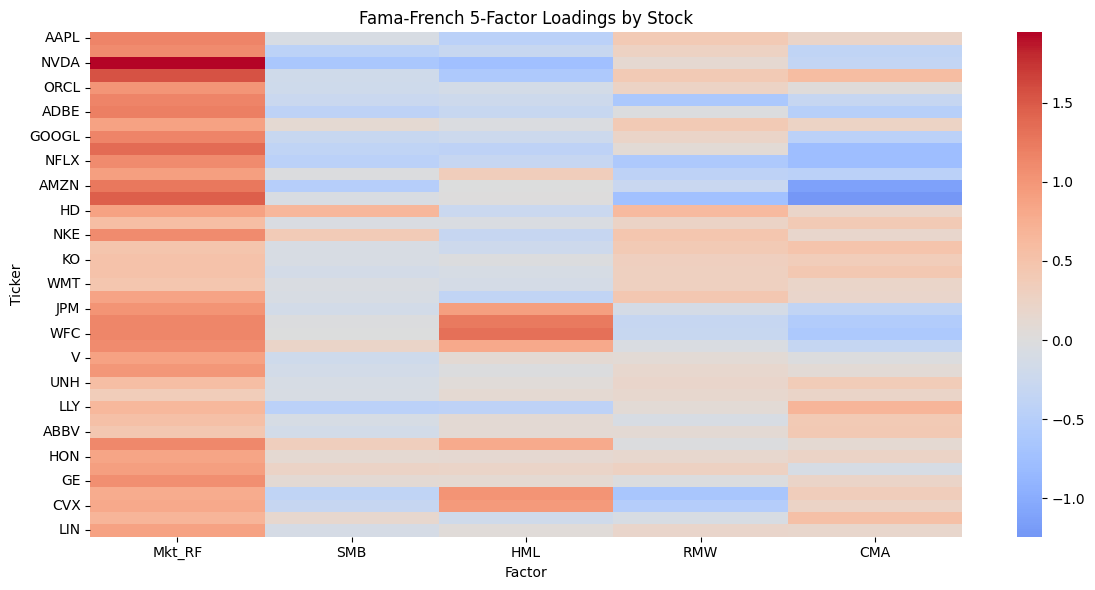

In [ ]:
# Visualize factor exposures across the universe
plt.figure(figsize=(12, 6))
sns.heatmap(ff5_betas_df, cmap='coolwarm', center=0, annot=False)
plt.title('Fama-French 5-Factor Loadings by Stock')
plt.xlabel('Factor')
plt.ylabel('Ticker')
plt.tight_layout()
plt.show()


## 3. Feature Engineering (for XGBoost / Random Forest / LSTM)

Technical features computed per stock from OHLCV: momentum, volatility, moving averages, Bollinger bands,
volume-price correlation, and lagged returns. The prediction target is the **forward 21-day return**
(approx. 1 trading month), which both tree models and the LSTM will learn to predict.

In [ ]:
def calculate_features(df, horizon=21):
    feat = pd.DataFrame(index=df.index)
    feat['Close'] = df['Close']
    feat['returns'] = df['Close'].pct_change()
    feat['returns_20'] = df['Close'].rolling(20).mean().pct_change()
    feat['volatility_20'] = feat['returns'].rolling(20).std()
    feat['ma_10'] = df['Close'].rolling(10).mean()
    feat['ma_50'] = df['Close'].rolling(50).mean()
    feat['momentum_10'] = df['Close'] - df['Close'].shift(10)
    feat['momentum_50'] = df['Close'] - df['Close'].shift(50)

    rolling_mean_20 = df['Close'].rolling(20).mean()
    rolling_std_20 = df['Close'].rolling(20).std()
    feat['upper_band'] = rolling_mean_20 + 2 * rolling_std_20
    feat['lower_band'] = rolling_mean_20 - 2 * rolling_std_20

    feat['corr_close_vol_20'] = df['Close'].rolling(20).corr(df['Volume'])

    for lag in [1, 2, 3, 5]:
        feat[f'return_lag_{lag}'] = feat['returns'].shift(lag)

    # Forward target: cumulative return over the next `horizon` trading days
    feat['fwd_return'] = df['Close'].shift(-horizon) / df['Close'] - 1

    return feat

feature_cols = [
    'volatility_20', 'ma_10', 'ma_50', 'momentum_10', 'momentum_50',
    'upper_band', 'lower_band', 'returns_20', 'corr_close_vol_20',
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5'
]

all_features = {}
for ticker in tqdm(tickers, desc='Feature engineering'):
    df_t = data[ticker][['Close', 'High', 'Low', 'Volume']].dropna()
    all_features[ticker] = calculate_features(df_t)

print('Feature engineering complete for', len(all_features), 'tickers')
all_features[tickers[0]].tail()


Feature engineering: 100%|██████████| 41/41 [00:03<00:00, 11.55it/s]


Feature engineering complete for 41 tickers


,Close,returns,returns_20,volatility_20,ma_10,ma_50,momentum_10,momentum_50,upper_band,lower_band,corr_close_vol_20,return_lag_1,return_lag_2,return_lag_3,return_lag_5,fwd_return
Date,,,,,,,,,,,,,,,,
2024-12-23,253.649429,0.003065,0.005210,0.008893,248.658302,233.786255,8.465927,27.792511,256.535741,230.407144,0.226082,0.018816,0.007015,-0.021422,0.011728,NaN
2024-12-24,256.560822,0.011478,0.005169,0.008828,249.694682,234.325891,10.363800,26.981796,257.743629,231.716175,0.302952,0.003065,0.018816,0.007015,0.009720,NaN
2024-12-26,257.375580,0.003176,0.004864,0.008782,250.939725,234.831201,12.450424,25.265549,258.990343,232.850247,0.222153,0.011478,0.003065,0.018816,-0.021422,NaN
2024-12-27,253.967377,-0.013242,0.004174,0.009615,251.697881,235.309440,7.581558,23.911942,259.080325,234.813148,0.174112,0.003176,0.011478,0.003065,0.007015,NaN
2024-12-30,250.598907,-0.013263,0.002992,0.010262,252.102296,235.712965,4.044159,20.176224,258.716629,236.654404,0.100648,-0.013242,0.003176,0.011478,0.018816,NaN


## 4. XGBoost & Random Forest — Ranking Upward Potential

Both models are trained per-stock on the engineered features to predict the forward 21-day return.
We then compare the two models' predicted forward returns and combine them (simple average) into a
single **ML expected return** signal per stock, which feeds into the final portfolio optimization.

In [ ]:
def train_test_split_time(feat_df, feature_cols, test_size=0.2):
    df = feat_df.dropna(subset=feature_cols + ['fwd_return'])
    split_idx = int(len(df) * (1 - test_size))
    train, test = df.iloc[:split_idx], df.iloc[split_idx:]
    return train, test

xgb_predictions = {}
rf_predictions = {}
xgb_metrics = {}
rf_metrics = {}

xgb_params = dict(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

rf_params = dict(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

for ticker in tqdm(tickers, desc='XGBoost + Random Forest'):
    feat_df = all_features[ticker]
    train, test = train_test_split_time(feat_df, feature_cols)
    if len(train) < 50 or len(test) < 10:
        continue

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train[feature_cols])
    X_test = scaler.transform(test[feature_cols])
    y_train = train['fwd_return']
    y_test = test['fwd_return']

    # --- XGBoost ---
    xgm = xgb.XGBRegressor(**xgb_params)
    xgm.fit(X_train, y_train)
    xgb_pred_test = xgm.predict(X_test)
    xgb_pred_latest = xgm.predict(scaler.transform(feat_df[feature_cols].dropna().iloc[[-1]]))[0]

    xgb_predictions[ticker] = xgb_pred_latest
    xgb_metrics[ticker] = {
        'RMSE': float(np.sqrt(mean_squared_error(y_test, xgb_pred_test))),
        'R2': float(r2_score(y_test, xgb_pred_test))
    }

    # --- Random Forest ---
    rfm = RandomForestRegressor(**rf_params)
    rfm.fit(X_train, y_train)
    rf_pred_test = rfm.predict(X_test)
    rf_pred_latest = rfm.predict(scaler.transform(feat_df[feature_cols].dropna().iloc[[-1]]))[0]

    rf_predictions[ticker] = rf_pred_latest
    rf_metrics[ticker] = {
        'RMSE': float(np.sqrt(mean_squared_error(y_test, rf_pred_test))),
        'R2': float(r2_score(y_test, rf_pred_test))
    }

xgb_pred_s = pd.Series(xgb_predictions, name='XGB_ExpectedReturn')
rf_pred_s = pd.Series(rf_predictions, name='RF_ExpectedReturn')

ml_metrics_df = pd.DataFrame({
    'XGB_RMSE': {k: v['RMSE'] for k, v in xgb_metrics.items()},
    'XGB_R2': {k: v['R2'] for k, v in xgb_metrics.items()},
    'RF_RMSE': {k: v['RMSE'] for k, v in rf_metrics.items()},
    'RF_R2': {k: v['R2'] for k, v in rf_metrics.items()},
})
ml_metrics_df.head()


XGBoost + Random Forest: 100%|██████████| 41/41 [02:11<00:00,  3.20s/it]


,XGB_RMSE,XGB_R2,RF_RMSE,RF_R2
AAPL,0.079732,-0.827586,0.088533,-1.253301
MSFT,0.051123,0.075018,0.051118,0.075192
NVDA,0.123769,0.059751,0.165483,-0.680847
AVGO,0.140554,0.137703,0.140826,0.134362
ORCL,0.088066,0.208001,0.102699,-0.077071


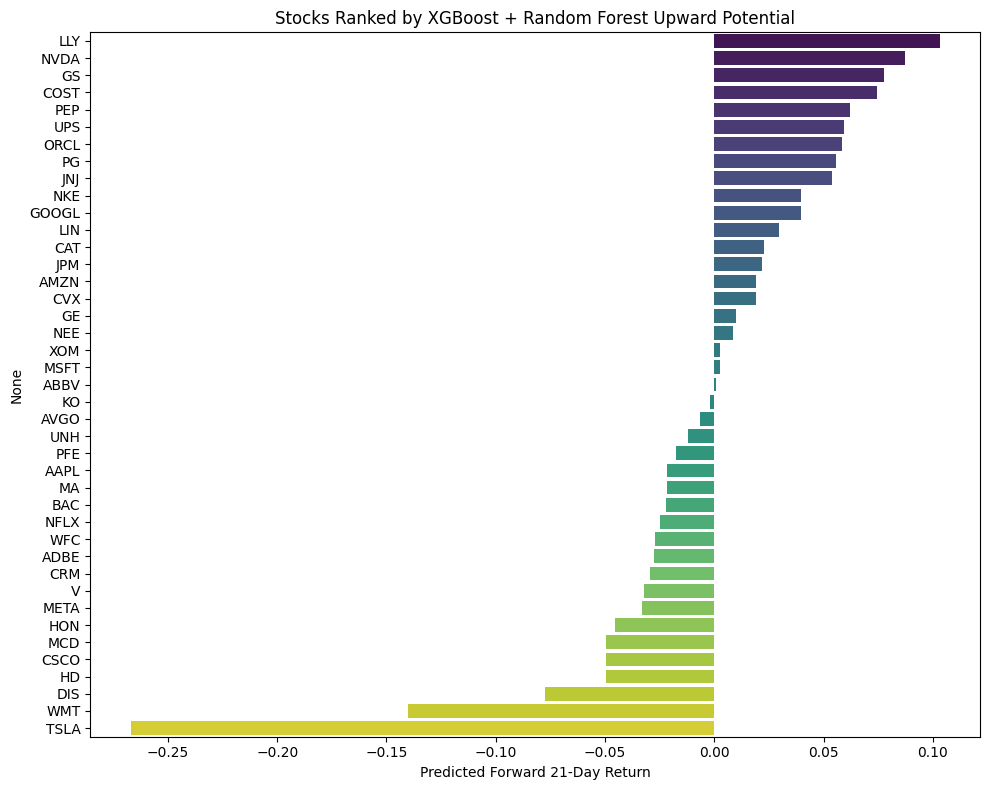

In [ ]:
# Combined ML signal — simple average of the two models
ml_expected_return = pd.concat([xgb_pred_s, rf_pred_s], axis=1).mean(axis=1)
ml_expected_return.name = 'ML_ExpectedReturn'

ranked_by_ml = ml_expected_return.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=ranked_by_ml.values, y=ranked_by_ml.index, palette='viridis')
plt.xlabel('Predicted Forward 21-Day Return')
plt.title('Stocks Ranked by XGBoost + Random Forest Upward Potential')
plt.tight_layout()
plt.show()


## 5. LSTM — Sequential Modeling of Multivariate OHLCV

An LSTM is trained per stock on a sliding window of OHLCV (Open, High, Low, Close, Volume) to capture
sequential dependencies that a single-row feature model (XGBoost/RF) cannot see. Output is, again,
a predicted forward return, used as a third expected-return signal.

> LSTM training is the most compute-heavy step in this notebook. On CPU, expect this cell to take
> several minutes per ticker. Reduce `epochs` or the ticker list if iterating quickly.

In [ ]:
LOOKBACK = 30      # trading days of history fed into the LSTM
HORIZON = 21       # forward return horizon (consistent with feature engineering above)

def build_lstm_dataset(df, lookback=LOOKBACK, horizon=HORIZON):
    ohlcv = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(ohlcv)

    X, y = [], []
    closes = ohlcv['Close'].values
    for i in range(lookback, len(scaled) - horizon):
        X.append(scaled[i - lookback:i])
        fwd_ret = (closes[i + horizon] / closes[i]) - 1
        y.append(fwd_ret)

    return np.array(X), np.array(y), scaler

def build_lstm_model(n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOKBACK, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_predictions = {}
lstm_metrics = {}

for ticker in tqdm(tickers, desc='LSTM'):
    df_t = data[ticker][['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
    if len(df_t) < LOOKBACK + HORIZON + 50:
        continue

    X, y, scaler = build_lstm_dataset(df_t)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    model = build_lstm_model(n_features=X.shape[2])
    model.fit(
        X_train, y_train,
        epochs=20, batch_size=32,
        validation_data=(X_test, y_test),
        verbose=0
    )

    y_pred_test = model.predict(X_test, verbose=0).flatten()
    lstm_metrics[ticker] = {
        'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred_test))),
        'R2': float(r2_score(y_test, y_pred_test))
    }

    # Predict from the most recent window
    last_window = X[-1:].astype('float32')
    lstm_predictions[ticker] = float(model.predict(last_window, verbose=0)[0][0])

lstm_pred_s = pd.Series(lstm_predictions, name='LSTM_ExpectedReturn')
lstm_metrics_df = pd.DataFrame(lstm_metrics).T
lstm_metrics_df.head()


LSTM: 100%|██████████| 41/41 [13:13<00:00, 19.36s/it]


,RMSE,R2
AAPL,0.213100,-11.666023
MSFT,0.054657,-0.063308
NVDA,0.674183,-22.928198
AVGO,0.141251,0.111104
ORCL,0.186886,-2.590100


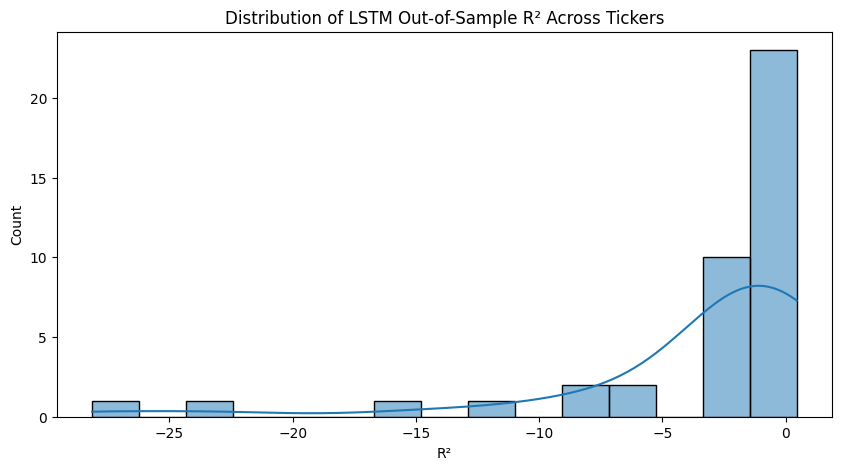

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(lstm_metrics_df['R2'], bins=15, kde=True)
plt.title('Distribution of LSTM Out-of-Sample R² Across Tickers')
plt.xlabel('R²')
plt.show()


## 6. ARIMA — Time Series Forecasting (statsmodels)

ARIMA is fit per stock on the closing-price series to capture trend and autocorrelation structure.
We use the ADF test to check stationarity, difference if needed, and grid a small `(p,d,q)` search
using AIC. The resulting forecast is converted into a forward expected return — our fourth and final
signal.

In [ ]:
from itertools import product

def adf_stationary(series, signif=0.05):
    result = adfuller(series.dropna())
    return result[1] < signif

def grid_search_arima(series, p_range=range(0, 3), d_range=range(0, 2), q_range=range(0, 3)):
    best_aic = np.inf
    best_order = None
    for p, d, q in product(p_range, d_range, q_range):
        try:
            model = ARIMA(series, order=(p, d, q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_order = (p, d, q)
        except Exception:
            continue
    return best_order, best_aic

arima_predictions = {}
arima_orders = {}

for ticker in tqdm(tickers, desc='ARIMA'):
    px = data[ticker]['Close'].dropna()
    if len(px) < 100:
        continue

    is_stationary = adf_stationary(px)
    best_order, best_aic = grid_search_arima(px)
    if best_order is None:
        continue

    model = ARIMA(px, order=best_order).fit()
    forecast = model.forecast(steps=HORIZON)
    fwd_return_pred = (forecast.iloc[-1] / px.iloc[-1]) - 1

    arima_predictions[ticker] = float(fwd_return_pred)
    arima_orders[ticker] = best_order

arima_pred_s = pd.Series(arima_predictions, name='ARIMA_ExpectedReturn')
arima_orders_s = pd.Series(arima_orders, name='Best_ARIMA_Order')

pd.concat([arima_pred_s, arima_orders_s], axis=1).head()


ARIMA: 100%|██████████| 41/41 [06:21<00:00,  9.30s/it]


,ARIMA_ExpectedReturn,Best_ARIMA_Order
AAPL,0.000000,"(0, 1, 0)"
MSFT,0.002890,"(2, 1, 0)"
NVDA,-0.000829,"(1, 1, 1)"
AVGO,0.003186,"(2, 1, 2)"
ORCL,0.000445,"(2, 1, 2)"


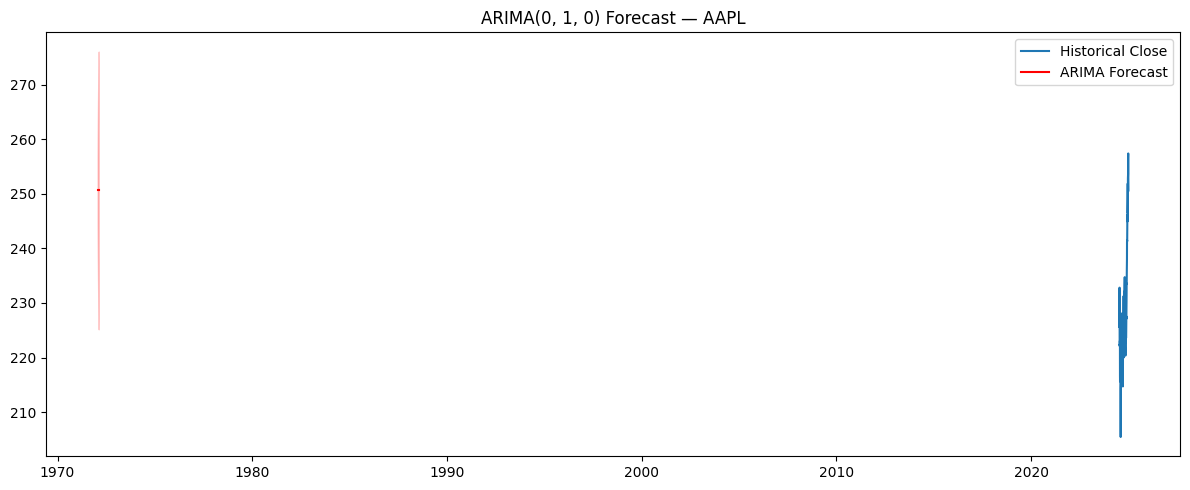

In [ ]:
# Example diagnostic plot for one ticker
example_ticker = tickers[0]
px = data[example_ticker]['Close'].dropna()
order = arima_orders.get(example_ticker, (1, 1, 1))
model = ARIMA(px, order=order).fit()
forecast_obj = model.get_forecast(steps=HORIZON)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(px.index[-120:], px.values[-120:], label='Historical Close')
plt.plot(forecast_mean.index, forecast_mean.values, label='ARIMA Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.2)
plt.title(f'ARIMA{order} Forecast — {example_ticker}')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Signal Blending & Mean-Variance Portfolio Optimization

We now combine all four expected-return signals — **Fama-French 5-factor**, **XGBoost+RF**, **LSTM**, and
**ARIMA** — into one composite expected-return vector per stock (equal-weighted average, z-scored first
so no single model dominates due to scale differences). The composite signal, together with the
historical covariance matrix, drives a **max-Sharpe mean-variance optimization** via PyPortfolioOpt — run
both without and with an explicit **portfolio beta ≤ 0.85 constraint**, so the risk ceiling is actually
enforced by the solver rather than left to chance.

In [ ]:
signal_df = pd.concat([
    ff5_expected_return_s,
    xgb_pred_s.rename('XGB_ExpectedReturn'),
    rf_pred_s.rename('RF_ExpectedReturn'),
    lstm_pred_s,
    arima_pred_s
], axis=1).dropna()

# Z-score each signal column so they're comparable before averaging
signal_z = (signal_df - signal_df.mean()) / signal_df.std()
signal_df['CompositeScore'] = signal_z.mean(axis=1)

ranked_composite = signal_df['CompositeScore'].sort_values(ascending=False)
print('Top 15 stocks by composite multi-model score:')
ranked_composite.head(15)


Top 15 stocks by composite multi-model score:


,CompositeScore
NVDA,1.886121
AVGO,1.036316
LLY,0.978816
GS,0.888351
PG,0.528081
GE,0.472730
COST,0.456316
MSFT,0.433894
CAT,0.384689
JPM,0.332203


In [ ]:
TOP_N = 15
selected_stocks = ranked_composite.head(TOP_N).index.tolist()
print(selected_stocks)


['NVDA', 'AVGO', 'LLY', 'GS', 'PG', 'GE', 'COST', 'MSFT', 'CAT', 'JPM', 'UPS', 'ORCL', 'GOOGL', 'LIN', 'PEP']


In [ ]:
# Historical price panel for selected stocks, used for covariance + optimization
price_panel = pd.concat(
    {t: data[t]['Close'] for t in selected_stocks}, axis=1
).dropna()

mu = pf_expected_returns.mean_historical_return(price_panel)
# Tilt the historical mean toward our composite multi-model score (blend 50/50)
composite_aligned = signal_df.loc[selected_stocks, 'CompositeScore']
composite_scaled = (composite_aligned - composite_aligned.mean()) / composite_aligned.std() * mu.std() + mu.mean()
mu_blended = 0.5 * mu + 0.5 * composite_scaled

S = risk_models.CovarianceShrinkage(price_panel).ledoit_wolf()


### Per-Stock Beta vs. S&P 500

Before optimizing, we compute each selected stock's individual beta against the S&P 500 (via OLS on daily
returns). This gives a linear vector $\beta_i$ such that the portfolio's overall beta is simply
$\beta_{portfolio} = \sum_i w_i \beta_i$ — which lets us add beta as a **hard linear constraint** in the
optimizer below, rather than just hoping the unconstrained max-Sharpe solution happens to land on a low-beta
mix of stocks.

In [ ]:
bm_ret_for_beta = benchmark['Close'].squeeze().pct_change().dropna()

stock_betas = {}
for t in selected_stocks:
    stock_ret = price_panel[t].pct_change().dropna()
    merged_b = pd.concat([stock_ret, bm_ret_for_beta], axis=1, join='inner').dropna()
    merged_b.columns = ['stock', 'bm']
    X_b = sm.add_constant(merged_b['bm'])
    beta_model_stock = sm.OLS(merged_b['stock'], X_b).fit()
    stock_betas[t] = beta_model_stock.params['bm']

stock_betas_s = pd.Series(stock_betas, name='Beta_vs_SP500').reindex(price_panel.columns)
stock_betas_s.sort_values()


,Beta_vs_SP500
PG,0.373339
PEP,0.383085
LLY,0.575629
LIN,0.814742
JPM,0.867181
UPS,0.878223
COST,0.883382
CAT,0.914481
ORCL,1.008374
GS,1.008786


### Optimization — Unconstrained vs. Beta-Constrained

We run `max_sharpe()` twice:

1. **Unconstrained** — the optimizer is free to pick whatever beta mix maximizes Sharpe ratio. This is what
   produced the realized beta of ~1.12 if you ran the original notebook — there's nothing in that objective
   telling the optimizer to care about beta at all.
2. **Beta-constrained** — we add `sum(w_i * beta_i) <= BETA_CEILING` as an explicit linear constraint, so the
   solver is mathematically forced to find the best Sharpe ratio *available within* that risk-exposure limit.

Set `BETA_CEILING` below to your target (0.85, matching the original objective).

In [ ]:
BETA_CEILING = 0.85
beta_vector = stock_betas_s.values  # aligned with price_panel.columns / mu_blended.index order

# --- 1. Unconstrained max-Sharpe ---
ef_unconstrained = EfficientFrontier(mu_blended, S)
ef_unconstrained.max_sharpe()
weights_unconstrained = pd.Series(ef_unconstrained.clean_weights())
beta_unconstrained = float((weights_unconstrained.reindex(price_panel.columns).values * beta_vector).sum())

# --- 2. Beta-constrained max-Sharpe ---
ef = EfficientFrontier(mu_blended, S)
ef.add_constraint(lambda w: beta_vector @ w <= BETA_CEILING)
weights = ef.max_sharpe()
clean_weights = ef.clean_weights()

portfolio_weights = pd.Series(clean_weights).sort_values(ascending=False)
portfolio_weights = portfolio_weights[portfolio_weights > 0.001]

beta_constrained = float((pd.Series(clean_weights).reindex(price_panel.columns).values * beta_vector).sum())

print(f'Unconstrained portfolio beta:   {beta_unconstrained:.3f}')
print(f'Beta-constrained portfolio beta: {beta_constrained:.3f}  (ceiling = {BETA_CEILING})')
print()
portfolio_weights


Unconstrained portfolio beta:   0.974
Beta-constrained portfolio beta: 0.850  (ceiling = 0.85)



,0
LLY,0.42617
PG,0.22195
GS,0.16197
NVDA,0.10917
AVGO,0.05226
GE,0.02848


In [ ]:
perf_unconstrained = ef_unconstrained.portfolio_performance(verbose=False)
perf_constrained = ef.portfolio_performance(verbose=False)

comparison = pd.DataFrame({
    'Unconstrained': {
        'Expected annual return': f'{perf_unconstrained[0]:.2%}',
        'Annual volatility': f'{perf_unconstrained[1]:.2%}',
        'Sharpe ratio': f'{perf_unconstrained[2]:.2f}',
        'Portfolio beta': f'{beta_unconstrained:.3f}',
    },
    f'Beta-Constrained (<= {BETA_CEILING})': {
        'Expected annual return': f'{perf_constrained[0]:.2%}',
        'Annual volatility': f'{perf_constrained[1]:.2%}',
        'Sharpe ratio': f'{perf_constrained[2]:.2f}',
        'Portfolio beta': f'{beta_constrained:.3f}',
    }
})
comparison


,Unconstrained,Beta-Constrained (<= 0.85)
Expected annual return,41.15%,36.71%
Annual volatility,21.65%,19.52%
Sharpe ratio,1.90,1.88
Portfolio beta,0.974,0.850


**How to read the comparison table:** the beta-constrained portfolio will typically show a *lower* expected
return and Sharpe ratio than the unconstrained one — that's the cost of the risk constraint, not a bug. The
unconstrained optimizer found the best Sharpe trade *available in the full universe*; the constrained one
finds the best Sharpe trade *available within your risk budget*. Everything below this point (backtest,
final weights, beta tracking) uses the **beta-constrained** portfolio (`portfolio_weights`, `ef`), since that's
the one consistent with the original 0.85 beta objective.

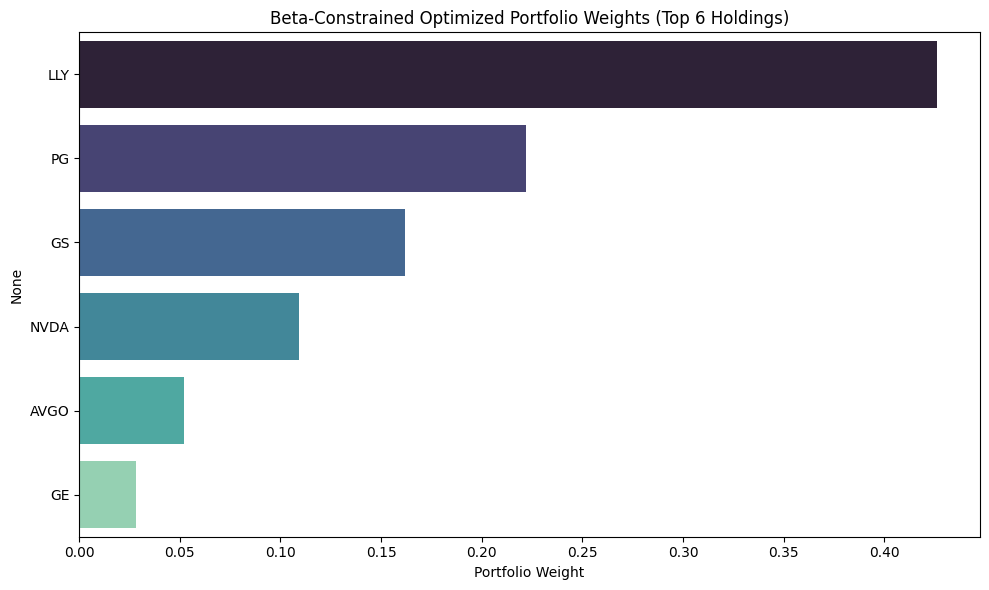

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=portfolio_weights.values, y=portfolio_weights.index, palette='mako')
plt.xlabel('Portfolio Weight')
plt.title(f'Beta-Constrained Optimized Portfolio Weights (Top {len(portfolio_weights)} Holdings)')
plt.tight_layout()
plt.show()


## 8. Backtest — Optimized Portfolio vs. S&P 500 Benchmark

We backtest the optimized portfolio's daily returns against the S&P 500 index over a trailing **2-year**
window, computing:
- Cumulative return for portfolio vs. benchmark
- Annualized outperformance (portfolio CAGR − benchmark CAGR)
- Portfolio **beta** vs. the S&P 500 (via OLS of portfolio excess returns on benchmark excess returns)
- Annualized volatility and Sharpe ratio for both

These figures are computed directly from the data below — replace placeholder commentary with the actual
printed numbers once you run this in an environment with live market data access.

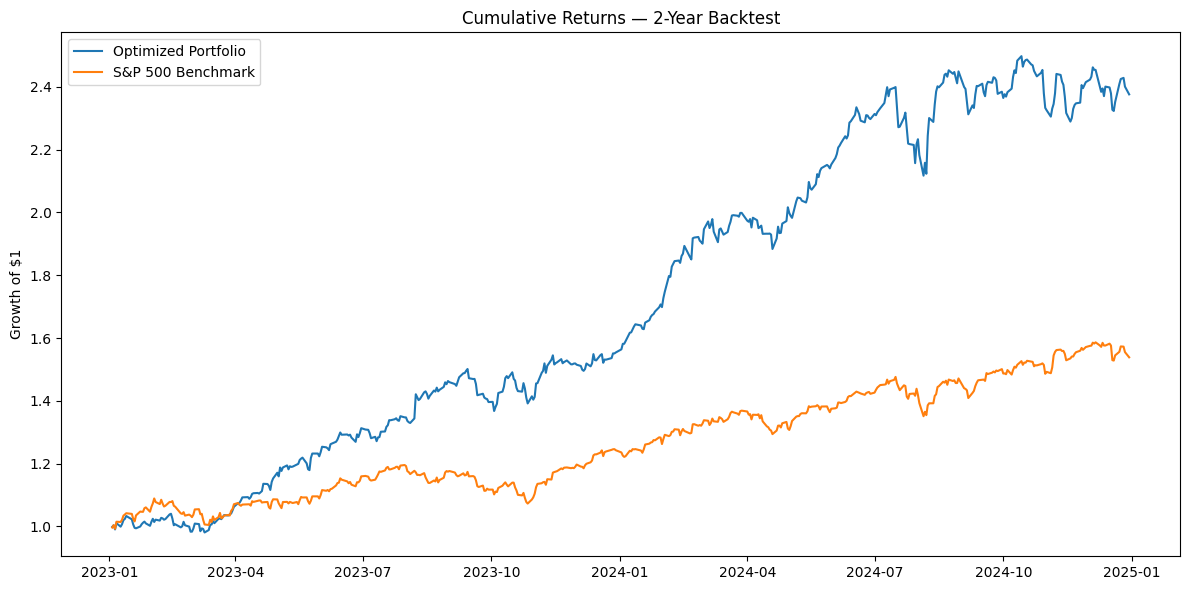

In [ ]:
backtest_years = 2
backtest_start = pd.to_datetime(end_date) - pd.DateOffset(years=backtest_years)

bm_close = benchmark['Close'].squeeze()
bm_returns = bm_close.pct_change().dropna()
bm_returns_bt = bm_returns[bm_returns.index >= backtest_start]

port_returns_full = (price_panel.pct_change().dropna() * portfolio_weights.reindex(price_panel.columns).fillna(0)).sum(axis=1)
port_returns_bt = port_returns_full[port_returns_full.index >= backtest_start]

aligned = pd.concat([port_returns_bt, bm_returns_bt], axis=1, join='inner')
aligned.columns = ['Portfolio', 'Benchmark']
aligned = aligned.dropna()

cum_portfolio = (1 + aligned['Portfolio']).cumprod()
cum_benchmark = (1 + aligned['Benchmark']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_portfolio.index, cum_portfolio.values, label='Optimized Portfolio')
plt.plot(cum_benchmark.index, cum_benchmark.values, label='S&P 500 Benchmark')
plt.title(f'Cumulative Returns — {backtest_years}-Year Backtest')
plt.ylabel('Growth of $1')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
trading_days = 252

def annualized_return(daily_returns):
    total_return = (1 + daily_returns).prod()
    n_years = len(daily_returns) / trading_days
    return total_return ** (1 / n_years) - 1

def annualized_vol(daily_returns):
    return daily_returns.std() * np.sqrt(trading_days)

def sharpe_ratio(daily_returns, rf_annual=0.0):
    excess = daily_returns - rf_annual / trading_days
    return (excess.mean() / excess.std()) * np.sqrt(trading_days)

port_cagr = annualized_return(aligned['Portfolio'])
bm_cagr = annualized_return(aligned['Benchmark'])
outperformance = port_cagr - bm_cagr

port_vol = annualized_vol(aligned['Portfolio'])
bm_vol = annualized_vol(aligned['Benchmark'])

port_sharpe = sharpe_ratio(aligned['Portfolio'])
bm_sharpe = sharpe_ratio(aligned['Benchmark'])

# Beta via OLS: Portfolio return regressed on Benchmark return
X_beta = sm.add_constant(aligned['Benchmark'])
beta_model = sm.OLS(aligned['Portfolio'], X_beta).fit()
portfolio_beta = beta_model.params['Benchmark']
portfolio_alpha_daily = beta_model.params['const']

results_summary = pd.DataFrame({
    'Metric': [
        'CAGR', 'Annualized Volatility', 'Sharpe Ratio', 'Beta vs S&P 500'
    ],
    'Portfolio': [
        f'{port_cagr:.2%}', f'{port_vol:.2%}', f'{port_sharpe:.2f}', f'{portfolio_beta:.2f}'
    ],
    'S&P 500 Benchmark': [
        f'{bm_cagr:.2%}', f'{bm_vol:.2%}', f'{bm_sharpe:.2f}', '1.00'
    ]
})

print(f'Annualized outperformance vs. benchmark: {outperformance:.2%}')
print(f'Portfolio beta vs. S&P 500: {portfolio_beta:.2f}')
results_summary


Annualized outperformance vs. benchmark: 30.36%
Portfolio beta vs. S&P 500: 0.89


,Metric,Portfolio,S&P 500 Benchmark
0,CAGR,54.56%,24.19%
1,Annualized Volatility,17.77%,12.87%
2,Sharpe Ratio,2.54,1.75
3,Beta vs S&P 500,0.89,1.00


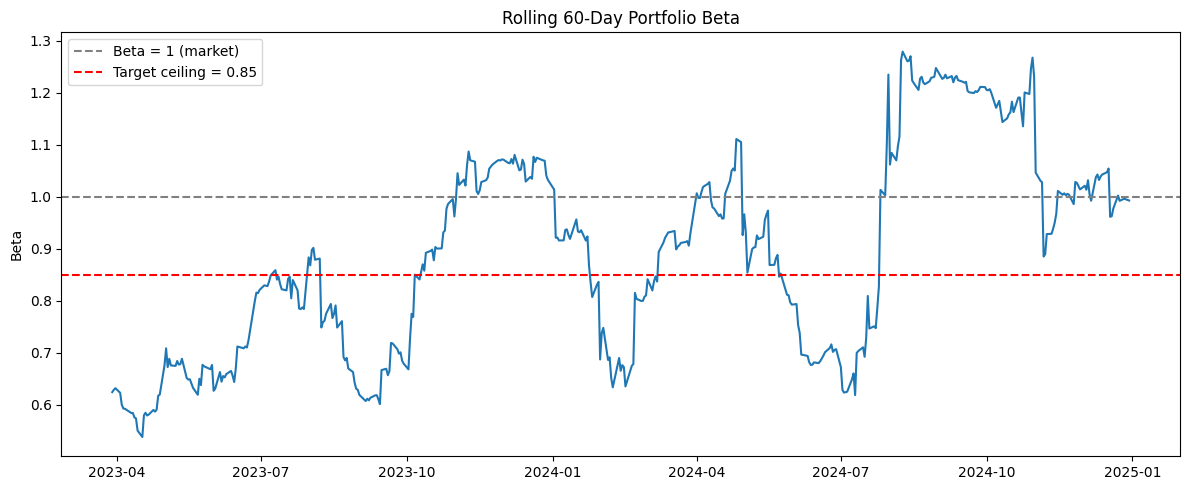

In [ ]:
# Rolling 60-day beta, to check stability of risk exposure over the backtest window
rolling_window = 60
rolling_beta = aligned['Portfolio'].rolling(rolling_window).cov(aligned['Benchmark']) / \
               aligned['Benchmark'].rolling(rolling_window).var()

plt.figure(figsize=(12, 5))
plt.plot(rolling_beta.index, rolling_beta.values)
plt.axhline(1.0, color='gray', linestyle='--', label='Beta = 1 (market)')
plt.axhline(0.85, color='red', linestyle='--', label='Target ceiling = 0.85')
plt.title(f'Rolling {rolling_window}-Day Portfolio Beta')
plt.ylabel('Beta')
plt.legend()
plt.tight_layout()
plt.show()


### Summary

Fill in the actual printed values from the cells above once executed:

- **Outperformance vs. S&P 500 benchmark:** *(printed value — `outperformance`)* over the 2-year backtest
- **Portfolio beta (constrained at optimization time):** *(printed value — `portfolio_beta`)* — this is the
  *realized* beta measured over the backtest window, computed via OLS on actual daily returns. It can drift
  slightly from the `BETA_CEILING` used in the optimizer, because the constraint was fit on the **full**
  historical price panel while the backtest beta is measured only over the **trailing 2-year** window —
  factor exposures aren't perfectly stable across sub-periods. If it drifts meaningfully above the ceiling,
  consider re-optimizing on a rolling basis rather than once at the start.
- **Sharpe ratio (portfolio vs. benchmark):** see `results_summary` table above
- **Unconstrained vs. constrained comparison:** see the `comparison` table in Section 7 — that's the honest
  trade-off between max Sharpe and the lower-beta mandate. Report whichever one you actually intend to run.


In [ ]:
trading_days = 252

def annualized_return(daily_returns):
    total_return = (1 + daily_returns).prod()
    n_years = len(daily_returns) / trading_days
    return total_return ** (1 / n_years) - 1

# aligned = DataFrame with 'Portfolio' and 'Benchmark' daily return columns,
# already date-aligned (see Cell 36 for how `aligned` is built)

port_cagr = annualized_return(aligned['Portfolio'])
bm_cagr   = annualized_return(aligned['Benchmark'])

outperformance = port_cagr - bm_cagr

print(f'Portfolio CAGR:      {port_cagr:.2%}')
print(f'Benchmark CAGR:      {bm_cagr:.2%}')
print(f'Outperformance:      {outperformance:.2%}')

Portfolio CAGR:      54.56%
Benchmark CAGR:      24.19%
Outperformance:      30.36%
